<a href="https://colab.research.google.com/github/kartik2006-del/efficient-finetuning-lora/blob/main/lora_finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment Results



In [18]:
import pandas as pd
import json
import os

results_path = "/content/gdrive/MyDrive/efficient-finetuning-lora/results"
os.makedirs(results_path, exist_ok=True)

# Rank ablation
rank_results = [
    ["LoRA Rank Ablation", "r=4", 270336, 0.0547],
    ["LoRA Rank Ablation", "r=8", 540672, 0.1093],
    ["LoRA Rank Ablation", "r=16", 1081344, 0.2184],
    ["LoRA Rank Ablation", "r=32", 2162688, 0.4359]
]

rank_df = pd.DataFrame(
    rank_results,
    columns=[
        "experiment",
        "setting",
        "trainable_params",
        "trainable_percent"
    ]
)

rank_df.to_csv(
    f"{results_path}/rank_ablation_results.csv",
    index=False
)


# Target module comparison
target_results = [
    ["Target Module Comparison", "Q + V", 1081344, 0.2184, 4.729441, 1.977768, 1.549908],
    ["Target Module Comparison", "Q + K + V", 1474560, 0.2976, 4.118824, 1.952317, 1.520788],
    ["Target Module Comparison", "Q + K + V + O", 2162688, 0.4359, 4.807529, 1.833368, 1.370771]
]

target_df = pd.DataFrame(
    target_results,
    columns=[
        "experiment",
        "setting",
        "trainable_params",
        "trainable_percent",
        "training_time_sec",
        "train_loss",
        "eval_loss"
    ]
)

target_df.to_csv(
    f"{results_path}/target_module_results.csv",
    index=False
)


# LoRA vs QLoRA
lora_qlora_results = [
    ["LoRA (Q + V)", 1081344, 4.729441, 9.80, 1.9778, 1.5499],
    ["QLoRA (Q + V)", 1081344, 12.30, 1.88, 2.0404, 1.6260]
]

lora_qlora_df = pd.DataFrame(
    lora_qlora_results,
    columns=[
        "method",
        "trainable_params",
        "training_time_sec",
        "peak_gpu_memory_gb",
        "train_loss",
        "eval_loss"
    ]
)

lora_qlora_df.to_csv(
    f"{results_path}/lora_vs_qlora_results.csv",
    index=False
)


# Error analysis
error_results = [
    ["Valid variation", 6],
    ["Incorrect", 1],
    ["Partial", 1],
    ["Incomplete", 1],
    ["Instruction-following error", 1]
]

error_df = pd.DataFrame(
    error_results,
    columns=["category", "count"]
)

error_df.to_csv(
    f"{results_path}/error_analysis_results.csv",
    index=False
)


# Combined JSON
all_results = {
    "rank_ablation": rank_df.to_dict(orient="records"),
    "target_module_comparison": target_df.to_dict(orient="records"),
    "lora_vs_qlora": lora_qlora_df.to_dict(orient="records"),
    "error_analysis": error_df.to_dict(orient="records")
}

with open(
    f"{results_path}/experiment_results.json",
    "w"
) as f:
    json.dump(all_results, f, indent=4)


print("Checkpoint 13 results saved to Google Drive.")
print("\nFiles:")

for file in sorted(os.listdir(results_path)):
    print("-", file)

Checkpoint 13 results saved to Google Drive.

Files:
- error_analysis_results.csv
- experiment_results.json
- lora_evaluation_100.csv
- lora_metrics.json
- lora_vs_qlora_results.csv
- rank_ablation_results.csv
- target_module_results.csv


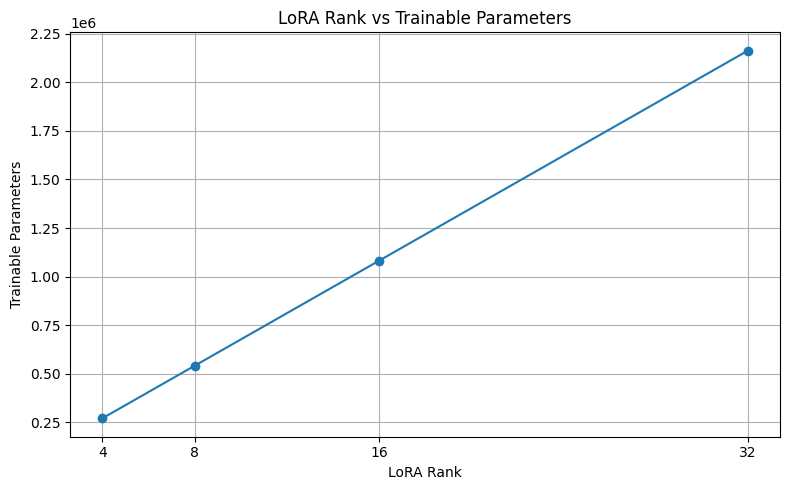

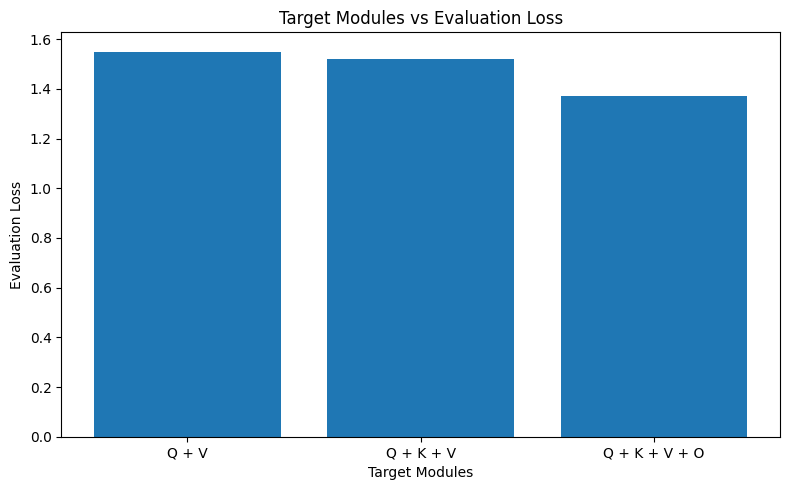

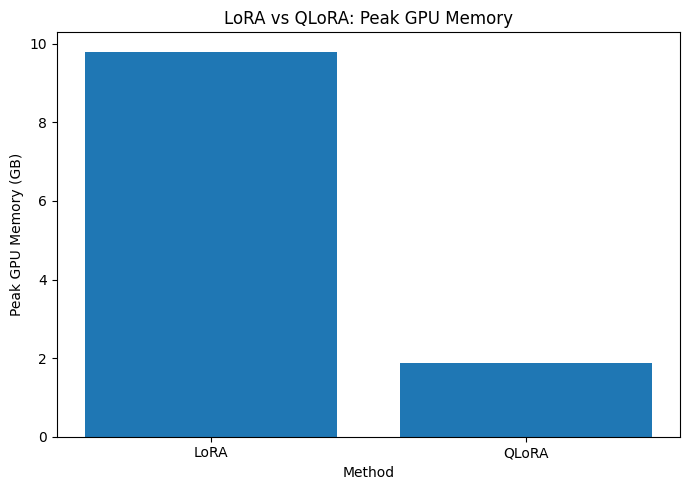


Graphs saved:
- lora_vs_qlora_memory.png
- rank_vs_trainable_params.png
- target_modules_vs_eval_loss.png


In [19]:
import matplotlib.pyplot as plt
import os

results_path = "/content/gdrive/MyDrive/efficient-finetuning-lora/results"

# 1. LoRA Rank vs Trainable Parameters

ranks = [4, 8, 16, 32]
trainable_params = [270336, 540672, 1081344, 2162688]

plt.figure(figsize=(8, 5))
plt.plot(ranks, trainable_params, marker="o")
plt.xlabel("LoRA Rank")
plt.ylabel("Trainable Parameters")
plt.title("LoRA Rank vs Trainable Parameters")
plt.xticks(ranks)
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{results_path}/rank_vs_trainable_params.png",
    dpi=300
)

plt.show()


# 2. Target Modules vs Evaluation Loss

target_modules = [
    "Q + V",
    "Q + K + V",
    "Q + K + V + O"
]

eval_losses = [
    1.549908,
    1.520788,
    1.370771
]

plt.figure(figsize=(8, 5))
plt.bar(target_modules, eval_losses)
plt.xlabel("Target Modules")
plt.ylabel("Evaluation Loss")
plt.title("Target Modules vs Evaluation Loss")
plt.tight_layout()

plt.savefig(
    f"{results_path}/target_modules_vs_eval_loss.png",
    dpi=300
)

plt.show()


# 3. LoRA vs QLoRA - GPU Memory

methods = ["LoRA", "QLoRA"]
memory = [9.80, 1.88]

plt.figure(figsize=(7, 5))
plt.bar(methods, memory)
plt.xlabel("Method")
plt.ylabel("Peak GPU Memory (GB)")
plt.title("LoRA vs QLoRA: Peak GPU Memory")
plt.tight_layout()

plt.savefig(
    f"{results_path}/lora_vs_qlora_memory.png",
    dpi=300
)

plt.show()


# Verify saved files

print("\nGraphs saved:")
for file in sorted(os.listdir(results_path)):
    if file.endswith(".png"):
        print("-", file)